In [1]:
pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install dgllife

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Loading file to Pandas DF + Add SMILES for primary and secondary ligand + solvent one hot encoder + Molecules structures

In [3]:
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import pandas as pd
import numpy as np
import seaborn as sn
#---------------------- RDKit packages
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
#------------------- progress bar
from tqdm import tqdm
#------------------- hide warning
import warnings
from urllib.request import urlopen
from urllib.parse import quote
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import Image, display
from IPython.display import display, HTML
import base64
from PIL import Image as PILImage
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings('ignore')

dataset=pd.read_excel("../../data/SF_DATA_EMISSION_PEAK.xlsx", sheet_name='SF_DATA_EMISSION_PEAK_NEW')
#dataset=dataset_full.iloc[:5]
#dataset = dataset.dropna(subset=['PHOTON_ENERGY_EV'])

master_smiles_map = {
    'ethanamine': 'CCN',
    'propan-1-amine': 'CCCN',
    'propan-2-amine': 'CC(N)C',
    'butan-1-amine': 'CCCCN',
    'pentan-1-amine': 'CCCCCN',
    'propane-1,3-diamine': 'NCCCN',
    'pentane-1,5-diamine': 'NCCCCCN',
    'N-(2-bromoethyl)propane-1,3-diamine': 'BrCCNCCCN',
    '2-phenylethan-1-amine': 'NCCc1ccccc1',
    '1-phenylethan-1-amine': 'CC(N)c1ccccc1',
    '3,3-diphenylpropan-1-amine': 'NCCC(c1ccccc1)c2ccccc2',
    '4-phenylbutan-1-amine': 'NCCCCc1ccccc1',
    '4-phenylbutan-2-amine': 'CC(N)CCc1ccccc1',
    'benzene-1,4-dimethanamine': 'NCc1ccc(CN)cc1',
    "[1,1':3',1'':3'',1'''-quaterphenyl]-4-ylmethanamine": 
        'NCc1ccc(cc1)-c2cccc(c2)-c3cccc(c3)-c4ccccc4',
    '1-(naphthalen-1-yl)ethan-1-amine': 'CC(N)c1cccc2ccccc12',
    'naphthalen-1-ylmethanamine': 'NCc1cccc2ccccc12',
    '2-(2-fluorophenyl)ethan-1-amine': 'NCCc1c(F)cccc1',
    '2-(3-fluorophenyl)ethan-1-amine': 'NCCc1cc(F)ccc1',
    '2-(4-fluorophenyl)ethan-1-amine': 'NCCc1ccc(F)cc1',
    '2-(2-methoxyphenyl)ethan-1-amine': 'NCCc1c(OC)cccc1',
    '2-(3-methoxyphenyl)ethan-1-amine': 'COc1cc(CCN)ccc1',
    '2-(4-methoxyphenyl)ethan-1-amine': 'COc1ccc(CCN)cc1',
    '2-phenoxyethan-1-amine': 'NCCOc1ccccc1',
    '2-(thiophen-2-yl)ethan-1-amine': 'NCCc1cccs1',
    "2-[5-(2,2'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1ccccc1-c2c(C)cc(cc2)-c3ccc(CCN)s3',
    "2-[5-(3',5'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1cc(C)cc(c1)-c2ccc(cc2)-c3ccc(CCN)s3',
    '2-[2-(2-aminoethoxy)ethoxy]ethan-1-amine': 'NCCOCCOCCN',
    'adamantan-1-amine': 'NC12CC3CC(C1)CC(C3)C2',
    'ethanimidamide': 'CC(=N)N',
    'guanidine': 'NC(=N)N'
}

#-----------------------
def CIRconvert(ids):
    if pd.isna(ids):
        return None
    try:
        url = 'http://cactus.nci.nih.gov/chemical/structure/' + quote(ids) + '/smiles'
        ans = urlopen(url).read().decode('utf8')
        return ans
    except:
        if ids in master_smiles_map:
            return master_smiles_map[ids]
        return 'Could not find SMILES'
        
dataset["PRIMARY_ORGANIC_SPACER_SMILES"]=dataset["PRIMARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)
dataset["SECONDARY_ORGANIC_SPACER_SMILES"]=dataset["SECONDARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)

#-------------------------
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
solvent_df = dataset[['SOLVENT']]
encoded_array = encoder.fit_transform(solvent_df)
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['SOLVENT']))
dataset = pd.concat([dataset.drop('SOLVENT', axis=1), encoded_df], axis=1)

#----------------------------
def smile_to_mol(smiles):
    if not smiles:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None
    
dataset["PRIMARY_ORGANIC_SPACER_MOL"]=dataset["PRIMARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)
dataset["SECONDARY_ORGANIC_SPACER_MOL"]=dataset["SECONDARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)

#----------------------------
def render_mol(mol):
    if not mol:
        return None
    img = Draw.MolToImage(mol)
    img_buffer = BytesIO()
    img.save(img_buffer, format="PNG")
    img_str = base64.b64encode(img_buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{img_str}" width="150">'

dataset["PRIMARY_ORGANIC_SPACER_STRUCT"]=dataset["PRIMARY_ORGANIC_SPACER_MOL"].apply(render_mol)
dataset["SECONDARY_ORGANIC_SPACER_STRUCT"]=dataset["SECONDARY_ORGANIC_SPACER_MOL"].apply(render_mol)

#---------------------------
#display(dataset)
#dataset.drop(columns='Mol', axis=1, inplace=True)
#dataset.drop(columns='Struct', axis=1, inplace=True)

#display(HTML(dataset.to_html(escape=False)))
with open('results_table.html', 'w', encoding='utf-8') as f:
    f.write(dataset.to_html(escape=False))
#-----------------

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
dataset.head()
print(dataset.shape)

(283, 37)


2D Molecular discriptors - All existing features + 200 Molecular discriptors

In [4]:
calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
desc_names = calc.GetDescriptorNames()

def get_2d_descriptors_safe(smiles):
    if pd.isna(smiles) or str(smiles).strip() == "":
        return [None] * len(desc_names)
    
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return [None] * len(desc_names)
        
        # Calculate descriptors (Notice we do NOT AddHs here!)
        return calc.CalcDescriptors(mol)
    except Exception:
        return [None] * len(desc_names)

primary_smiles = dataset['PRIMARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
secondary_smiles = dataset['SECONDARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
unique_smiles = list(set(primary_smiles + secondary_smiles))
print(f"Found {len(unique_smiles)} unique molecules. Calculating {len(desc_names)} descriptors...")


features_dict = {}
for sm in unique_smiles:
    features_dict[sm] = get_2d_descriptors_safe(sm)

df_unique_features = pd.DataFrame.from_dict(features_dict, orient='index', columns=desc_names)
df_primary_features = df_unique_features.add_prefix('Pri_')
df_secondary_features = df_unique_features.add_prefix('Sec_')

dataset = dataset.merge(
    df_primary_features, 
    how='left', 
    left_on='PRIMARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

dataset = dataset.merge(
    df_secondary_features, 
    how='left', 
    left_on='SECONDARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

print("\n--- Featurization Complete! ---")

columns_to_omit = ['REFERENCE_DOI', 'PRIMARY_ORGANIC_SPACER_IUPAC', 'SECONDARY_ORGANIC_SPACER_IUPAC', 'PRIMARY_ORGANIC_SPACER_SMILES', 'SECONDARY_ORGANIC_SPACER_SMILES', 'PRIMARY_ORGANIC_SPACER_MOL', 'SECONDARY_ORGANIC_SPACER_MOL', 'PRIMARY_ORGANIC_SPACER_STRUCT', 'SECONDARY_ORGANIC_SPACER_STRUCT']
dataset_final = dataset.drop(columns=columns_to_omit, errors='ignore')
dataset_final = dataset_final.fillna(0)
dataset_final.head()
print(dataset_final.shape)

Found 31 unique molecules. Calculating 217 descriptors...

--- Featurization Complete! ---
(283, 462)


Data split to training and testing - Stratified splitting + Choosing Y

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import sklearn
sklearn.set_config(enable_metadata_routing=True)

X = dataset_final.drop(columns=['EMISSION_PEAK_NM', 'PHOTON_ENERGY_EV'])
y = dataset_final['PHOTON_ENERGY_EV']


stratify_col = (X['IS_MIXED_SPACERS_SPACER'] > 0).astype(int) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=stratify_col
)

Feature elimination by 1) Corelation matrices and 2) RFECV  (Recusive Feature Elimination using Cross Validation)

In [6]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Dropping {len(to_drop)} highly correlated redundant features.")

X_train_uncorr = X_train.drop(columns=to_drop)
X_test_uncorr = X_test.drop(columns=to_drop)

#-----------RFECV---------
weights = compute_sample_weight(
    class_weight='balanced', 
    y=stratify_col.loc[X_train.index]
)







# 2. Train the Random Forest Feature Selector WITH the weights
selector_model = RandomForestRegressor(n_estimators=100, random_state=42)
selector_model.fit(X_train_uncorr, y_train, sample_weight=weights) # <-- Pass weights here!


# Select features that have an importance higher than the average
selector = SelectFromModel(selector_model, prefit=True)
selected_feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
best_features = X_train_uncorr.columns[selected_feature_indices]
print(f"Final selected features ({len(best_features)}): \n{best_features.tolist()}")

# STEP 4: Create final datasets with only the best features
X_train_final = X_train_uncorr[best_features]
X_test_final = X_test_uncorr[best_features]

print(f"\nFinal Training Data Shape: {X_train_final.shape}")
print(f"Final Testing Data Shape: {X_test_final.shape}")

Dropping 172 highly correlated redundant features.
Final selected features (13): 
['CL_PRIMARY_ORGANIC_HALIDE', 'BR_PRIMARY_ORGANIC_HALIDE', 'SPACER_TO_PB_RATIO', 'PbCl2', 'PbBr2', 'CsBr_TO_Pb', 'CsI_TO_Pb', 'FABr_TO_Pb', 'FAI_TO_Pb', 'SOLVENT_DMF', 'Pri_VSA_EState4', 'Sec_HallKierAlpha', 'Sec_EState_VSA8']

Final Training Data Shape: (226, 13)
Final Testing Data Shape: (57, 13)


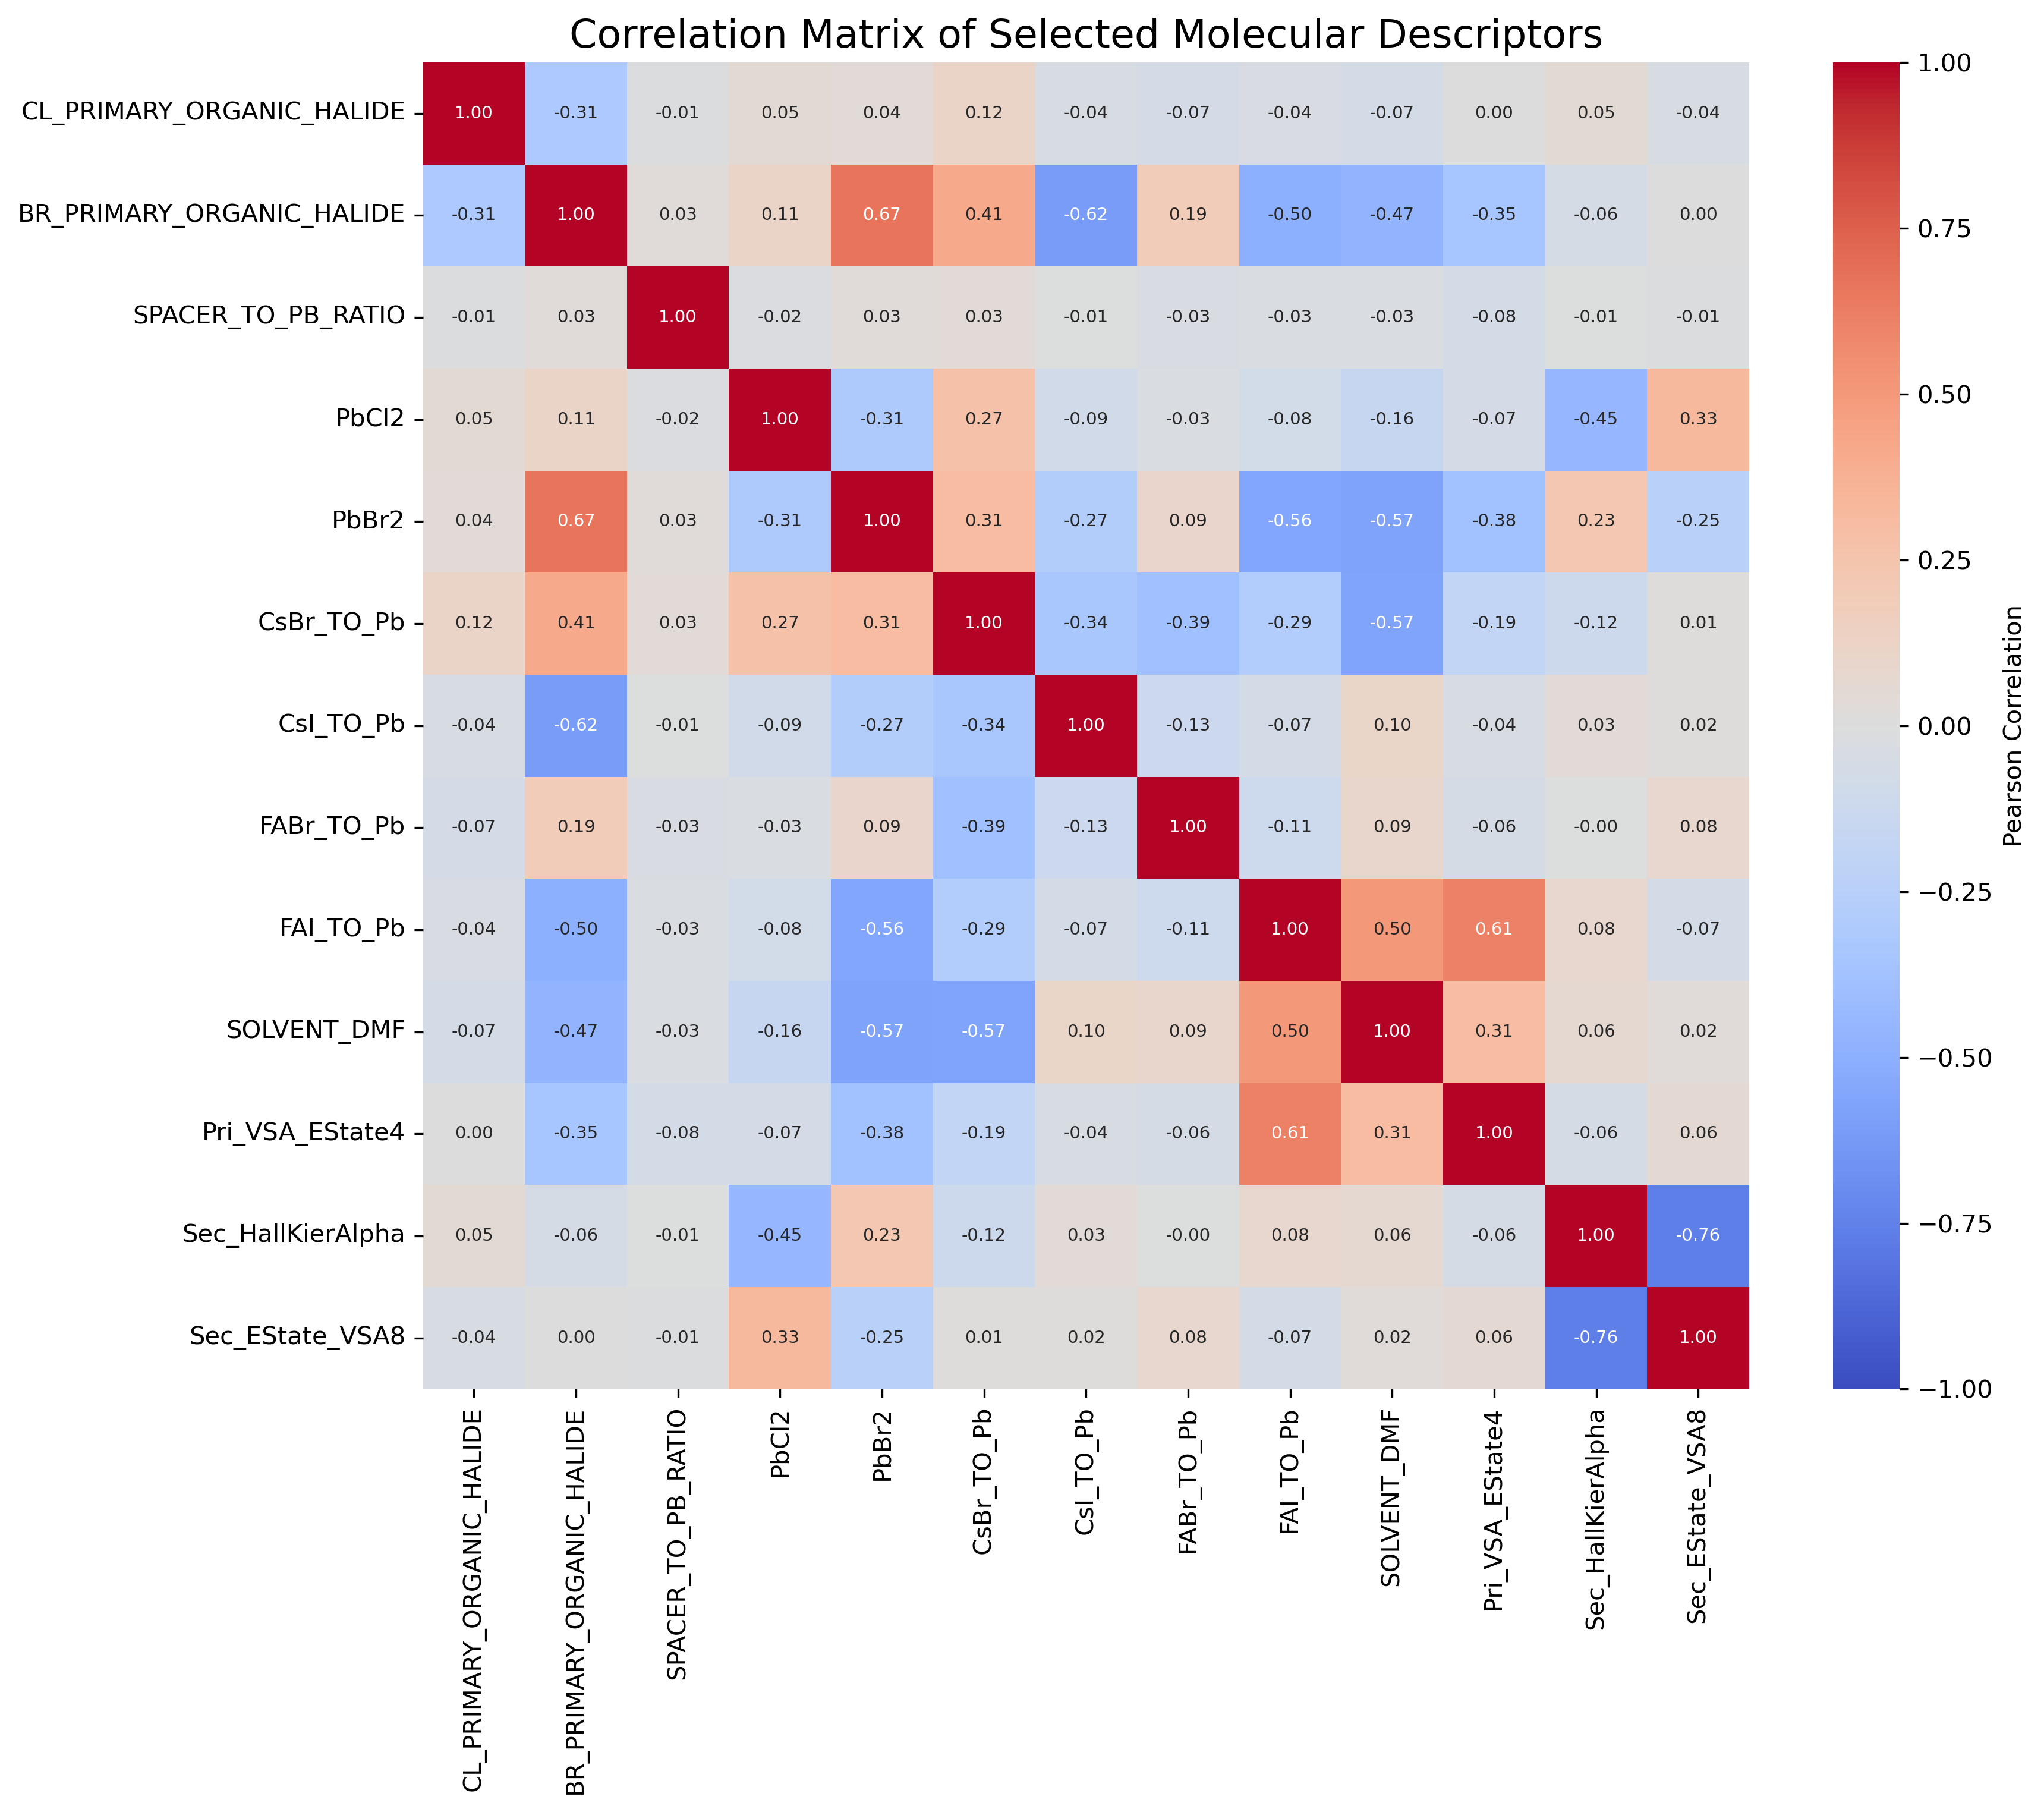

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10), dpi=300) 

# Calculate correlation on the final reduced dataset
final_corr = X_train_final.corr()

# heatmap
sns.heatmap(final_corr, 
            annot=True,          
            fmt=".2f",           
            cmap='coolwarm',     
            vmin=-1, vmax=1, 
            square=True, 
            annot_kws={"size": 7}, # <-- THIS SHRINKS THE NUMBERS (Try 6, 7, or 8)
            cbar_kws={'label': 'Pearson Correlation'})

plt.title("Correlation Matrix of Selected Molecular Descriptors", fontsize=16)

# 3. Ensure labels fit nicely
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("Figure_2_Correlation_Heatmap_Clean_RFECV_eV.png")
plt.show()

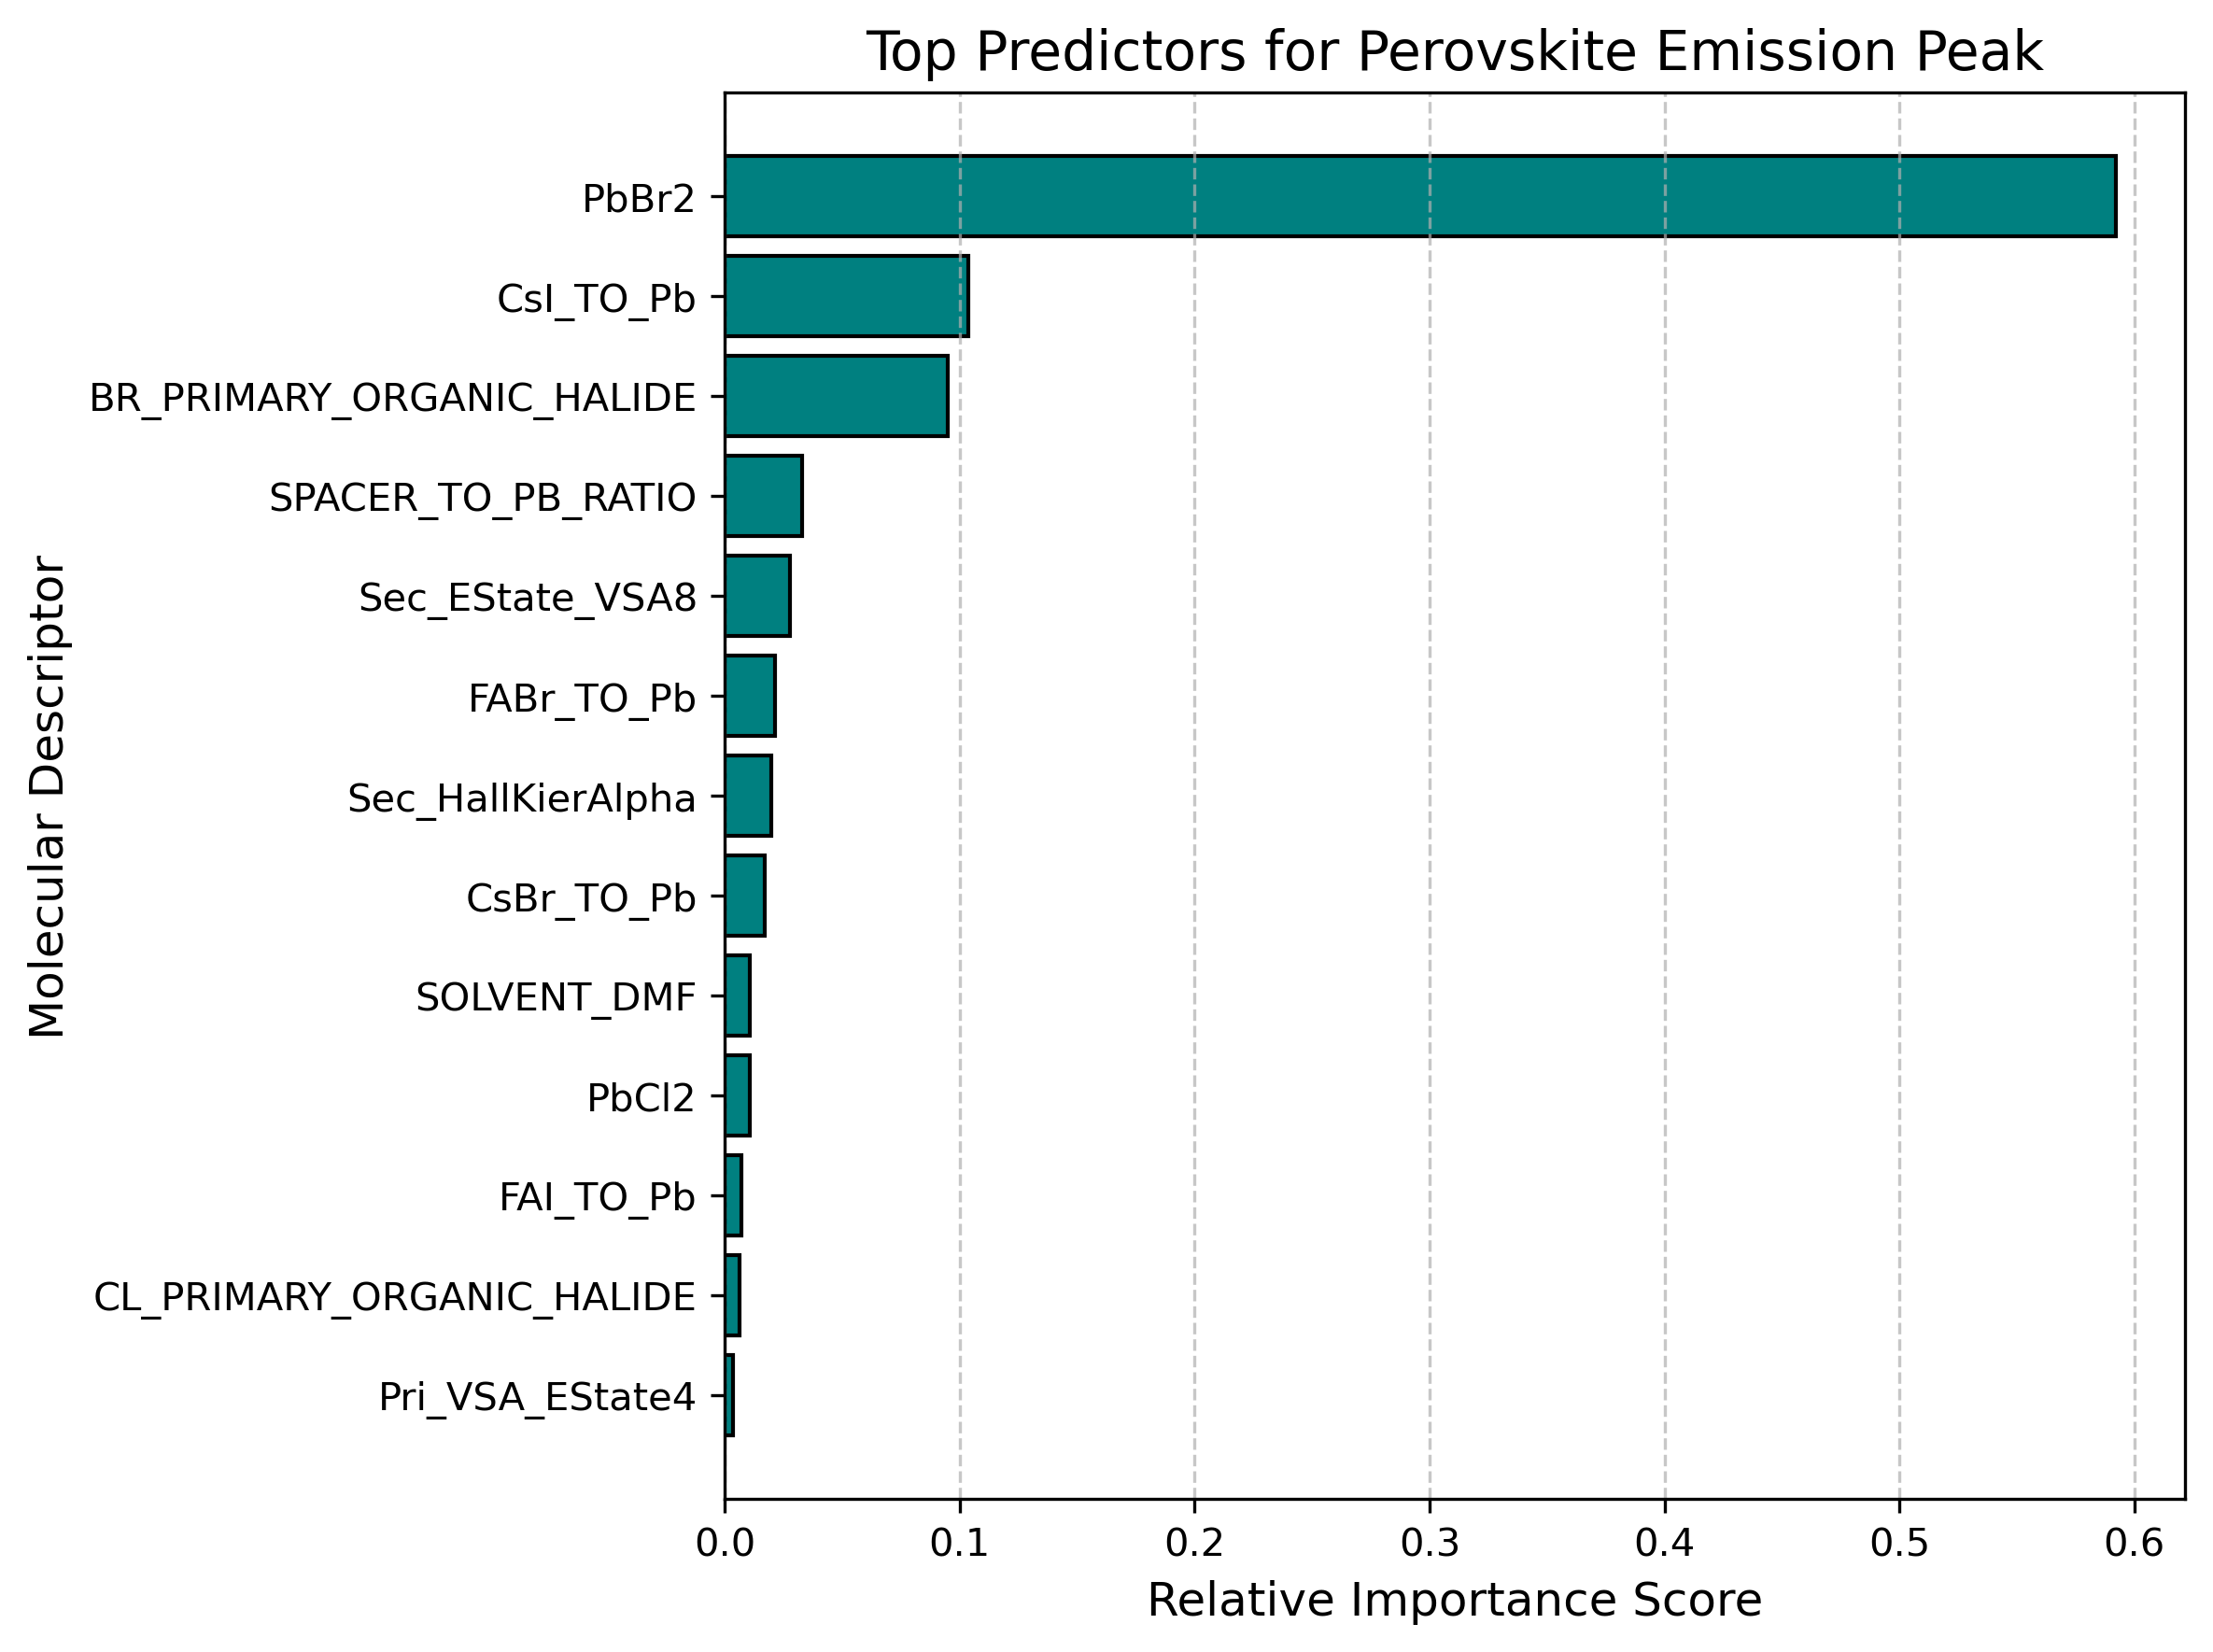

In [8]:
# Extract the importance scores from your Random Forest selector
importances = selector_model.feature_importances_[selected_feature_indices]
feature_names = X_train_final.columns

# Sort them from highest to lowest
sorted_indices = np.argsort(importances)
sorted_importances = importances[sorted_indices]
sorted_features = feature_names[sorted_indices]

# Create the Bar Chart
plt.figure(figsize=(8, 6), dpi=300)
plt.barh(sorted_features, sorted_importances, color='teal', edgecolor='black')

plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Molecular Descriptor", fontsize=12)
plt.title("Top Predictors for Perovskite Emission Peak", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Figure_2_Feature_Importance_RF_WL.png")
plt.show()

In [9]:
!pip install xgboost
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Starting Hyperparameter Tuning (this may take a few minutes)...
Tuning Random Forest...
--> Best params for Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 30}
Tuning XGBoost...
--> Best params for XGBoost: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05}
Tuning CatBoost...
--> Best params for CatBoost: {'learning_rate': 0.05, 'iterations': 500, 'depth': 6}
Tuning SVR (RBF)...
--> Best params for SVR (RBF): {'gamma': 'auto', 'epsilon': 0.01, 'C': 50}
Tuning Gaussian Process...

All models successfully tuned and trained!

FINAL RESULTS (Using Tuned Hyperparameters)
           Model  R2 Score  RMSE (eV)  MAE (eV)
       SVR (RBF)  0.943457   0.081287  0.053091
Gaussian Process  0.928067   0.091685  0.059866
        CatBoost  0.878484   0.119165  0.063835
         XGBoost  0.862872   0.126589  0.070007
   Random Forest  0.728165   0.178232  0.090018

Generating SHAP Summary Plots for each model... (SVR and GPR may take a moment)


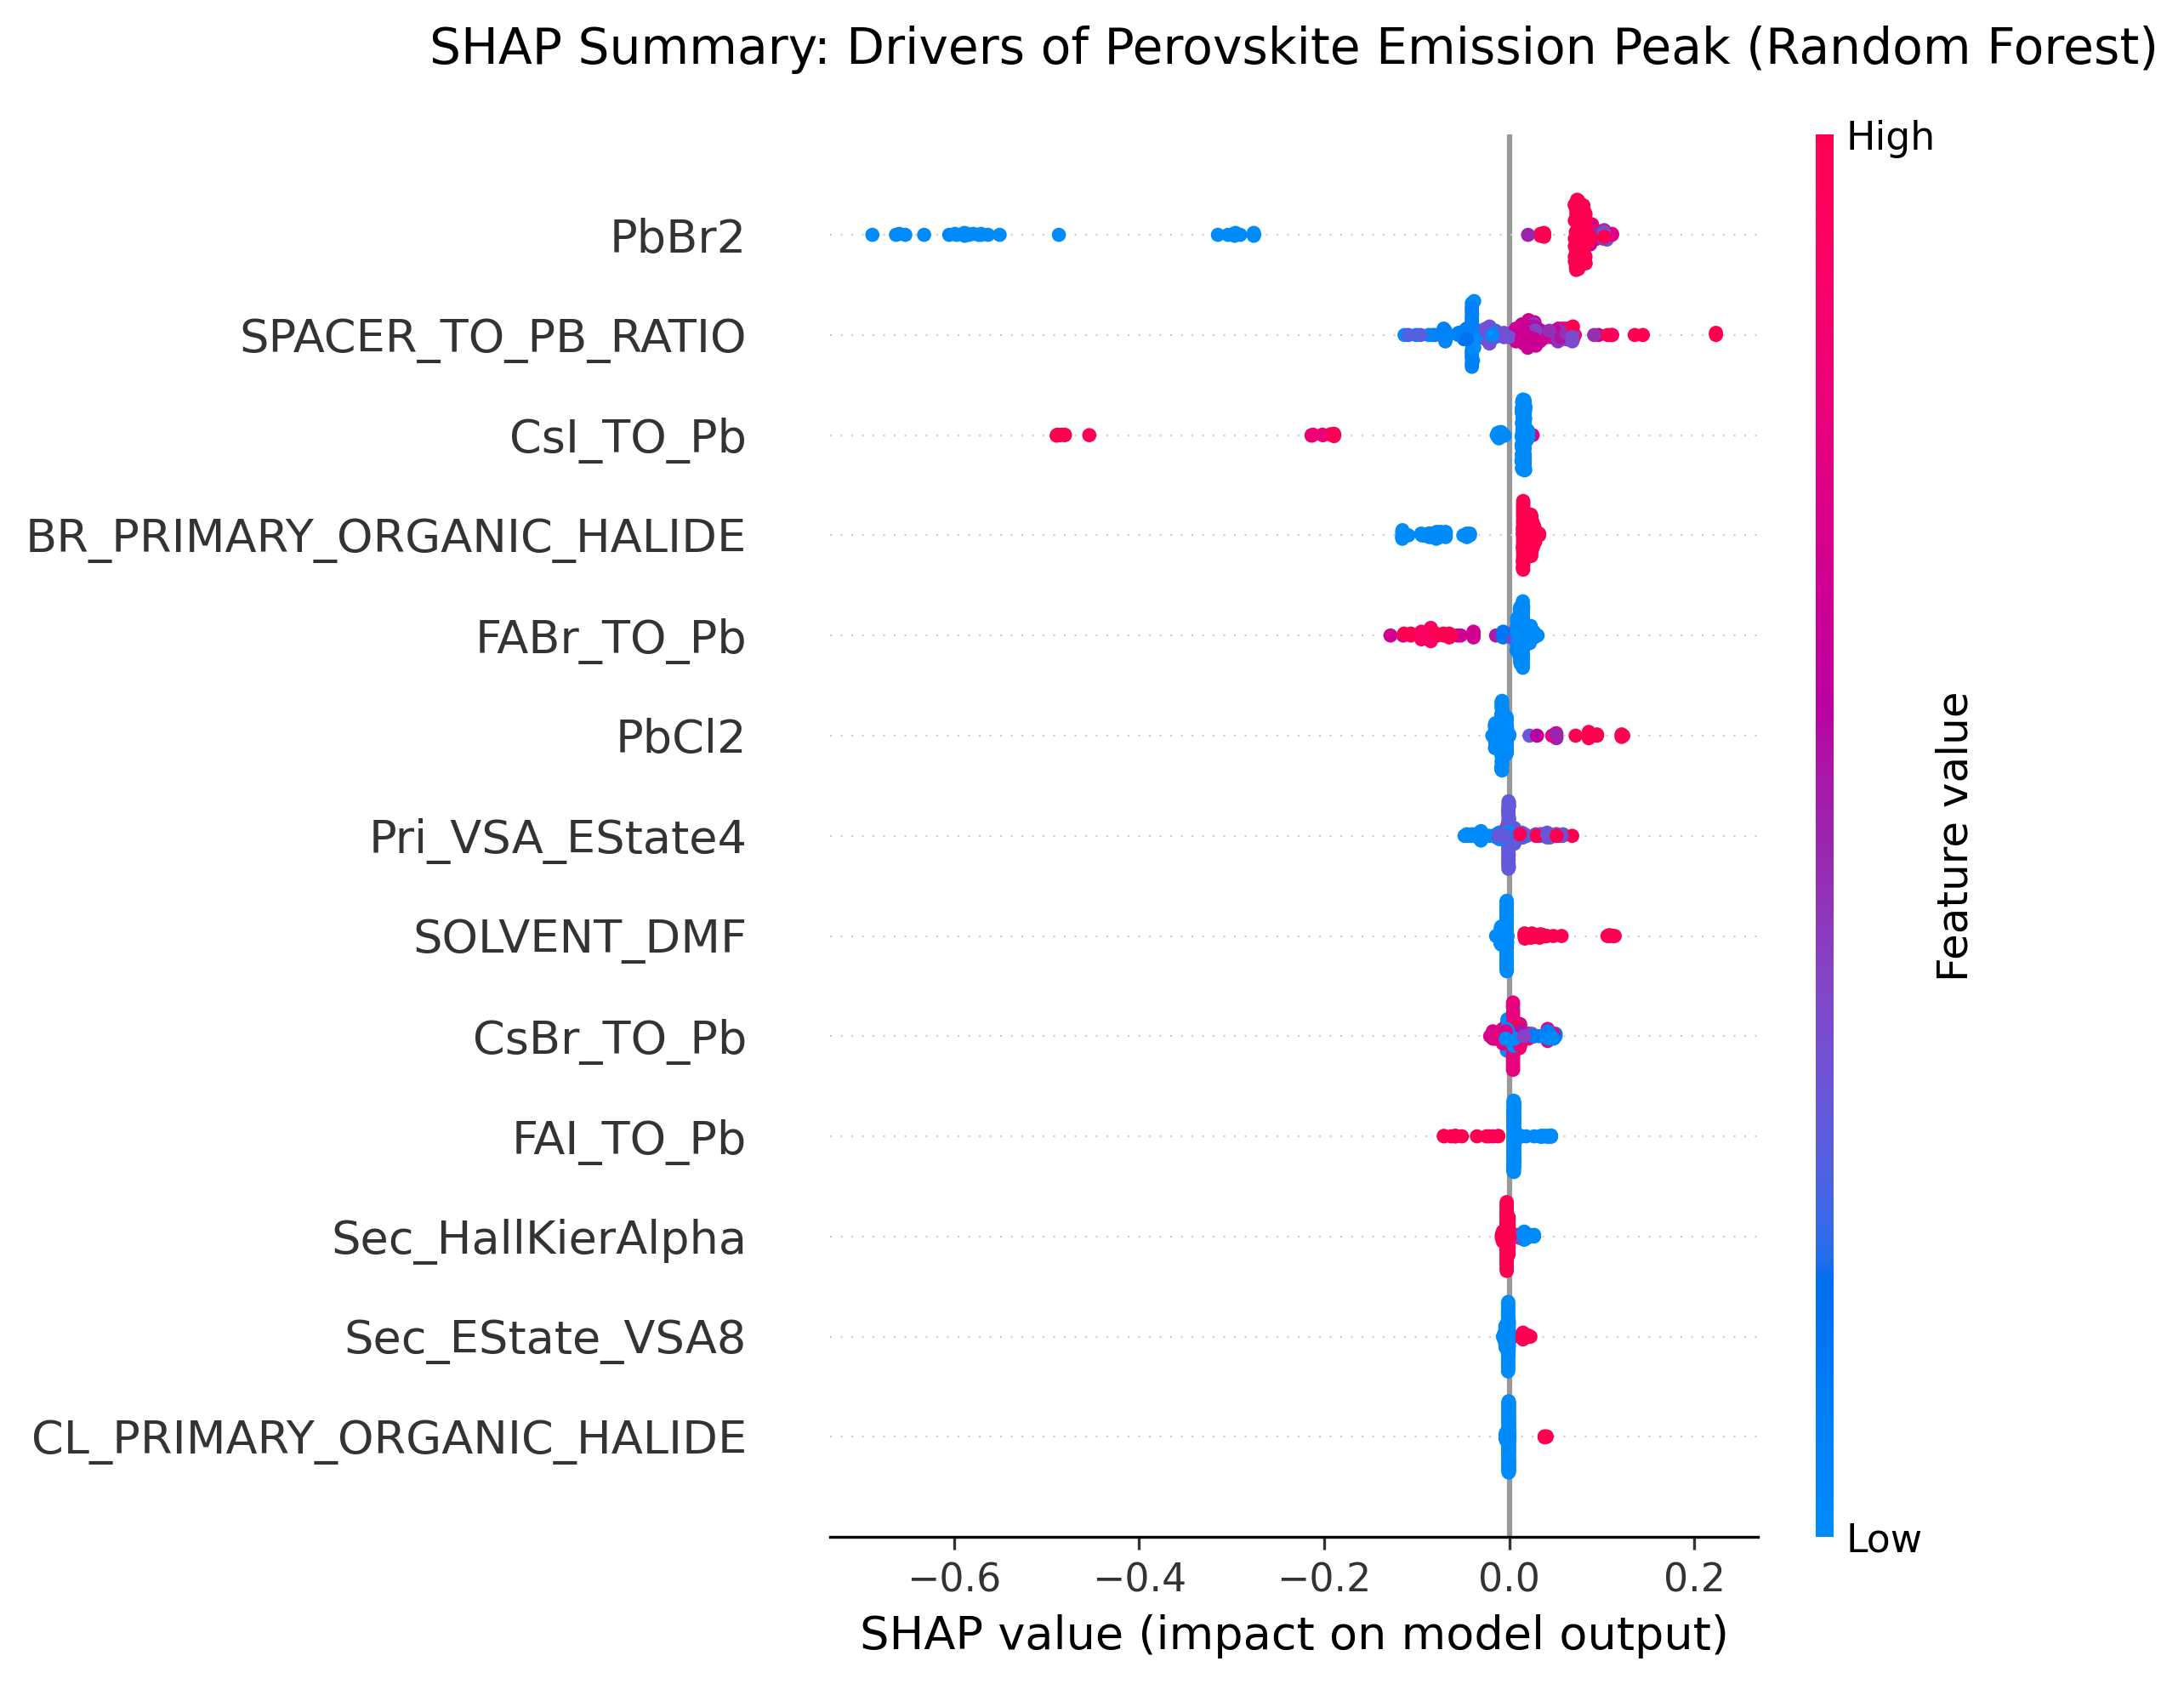

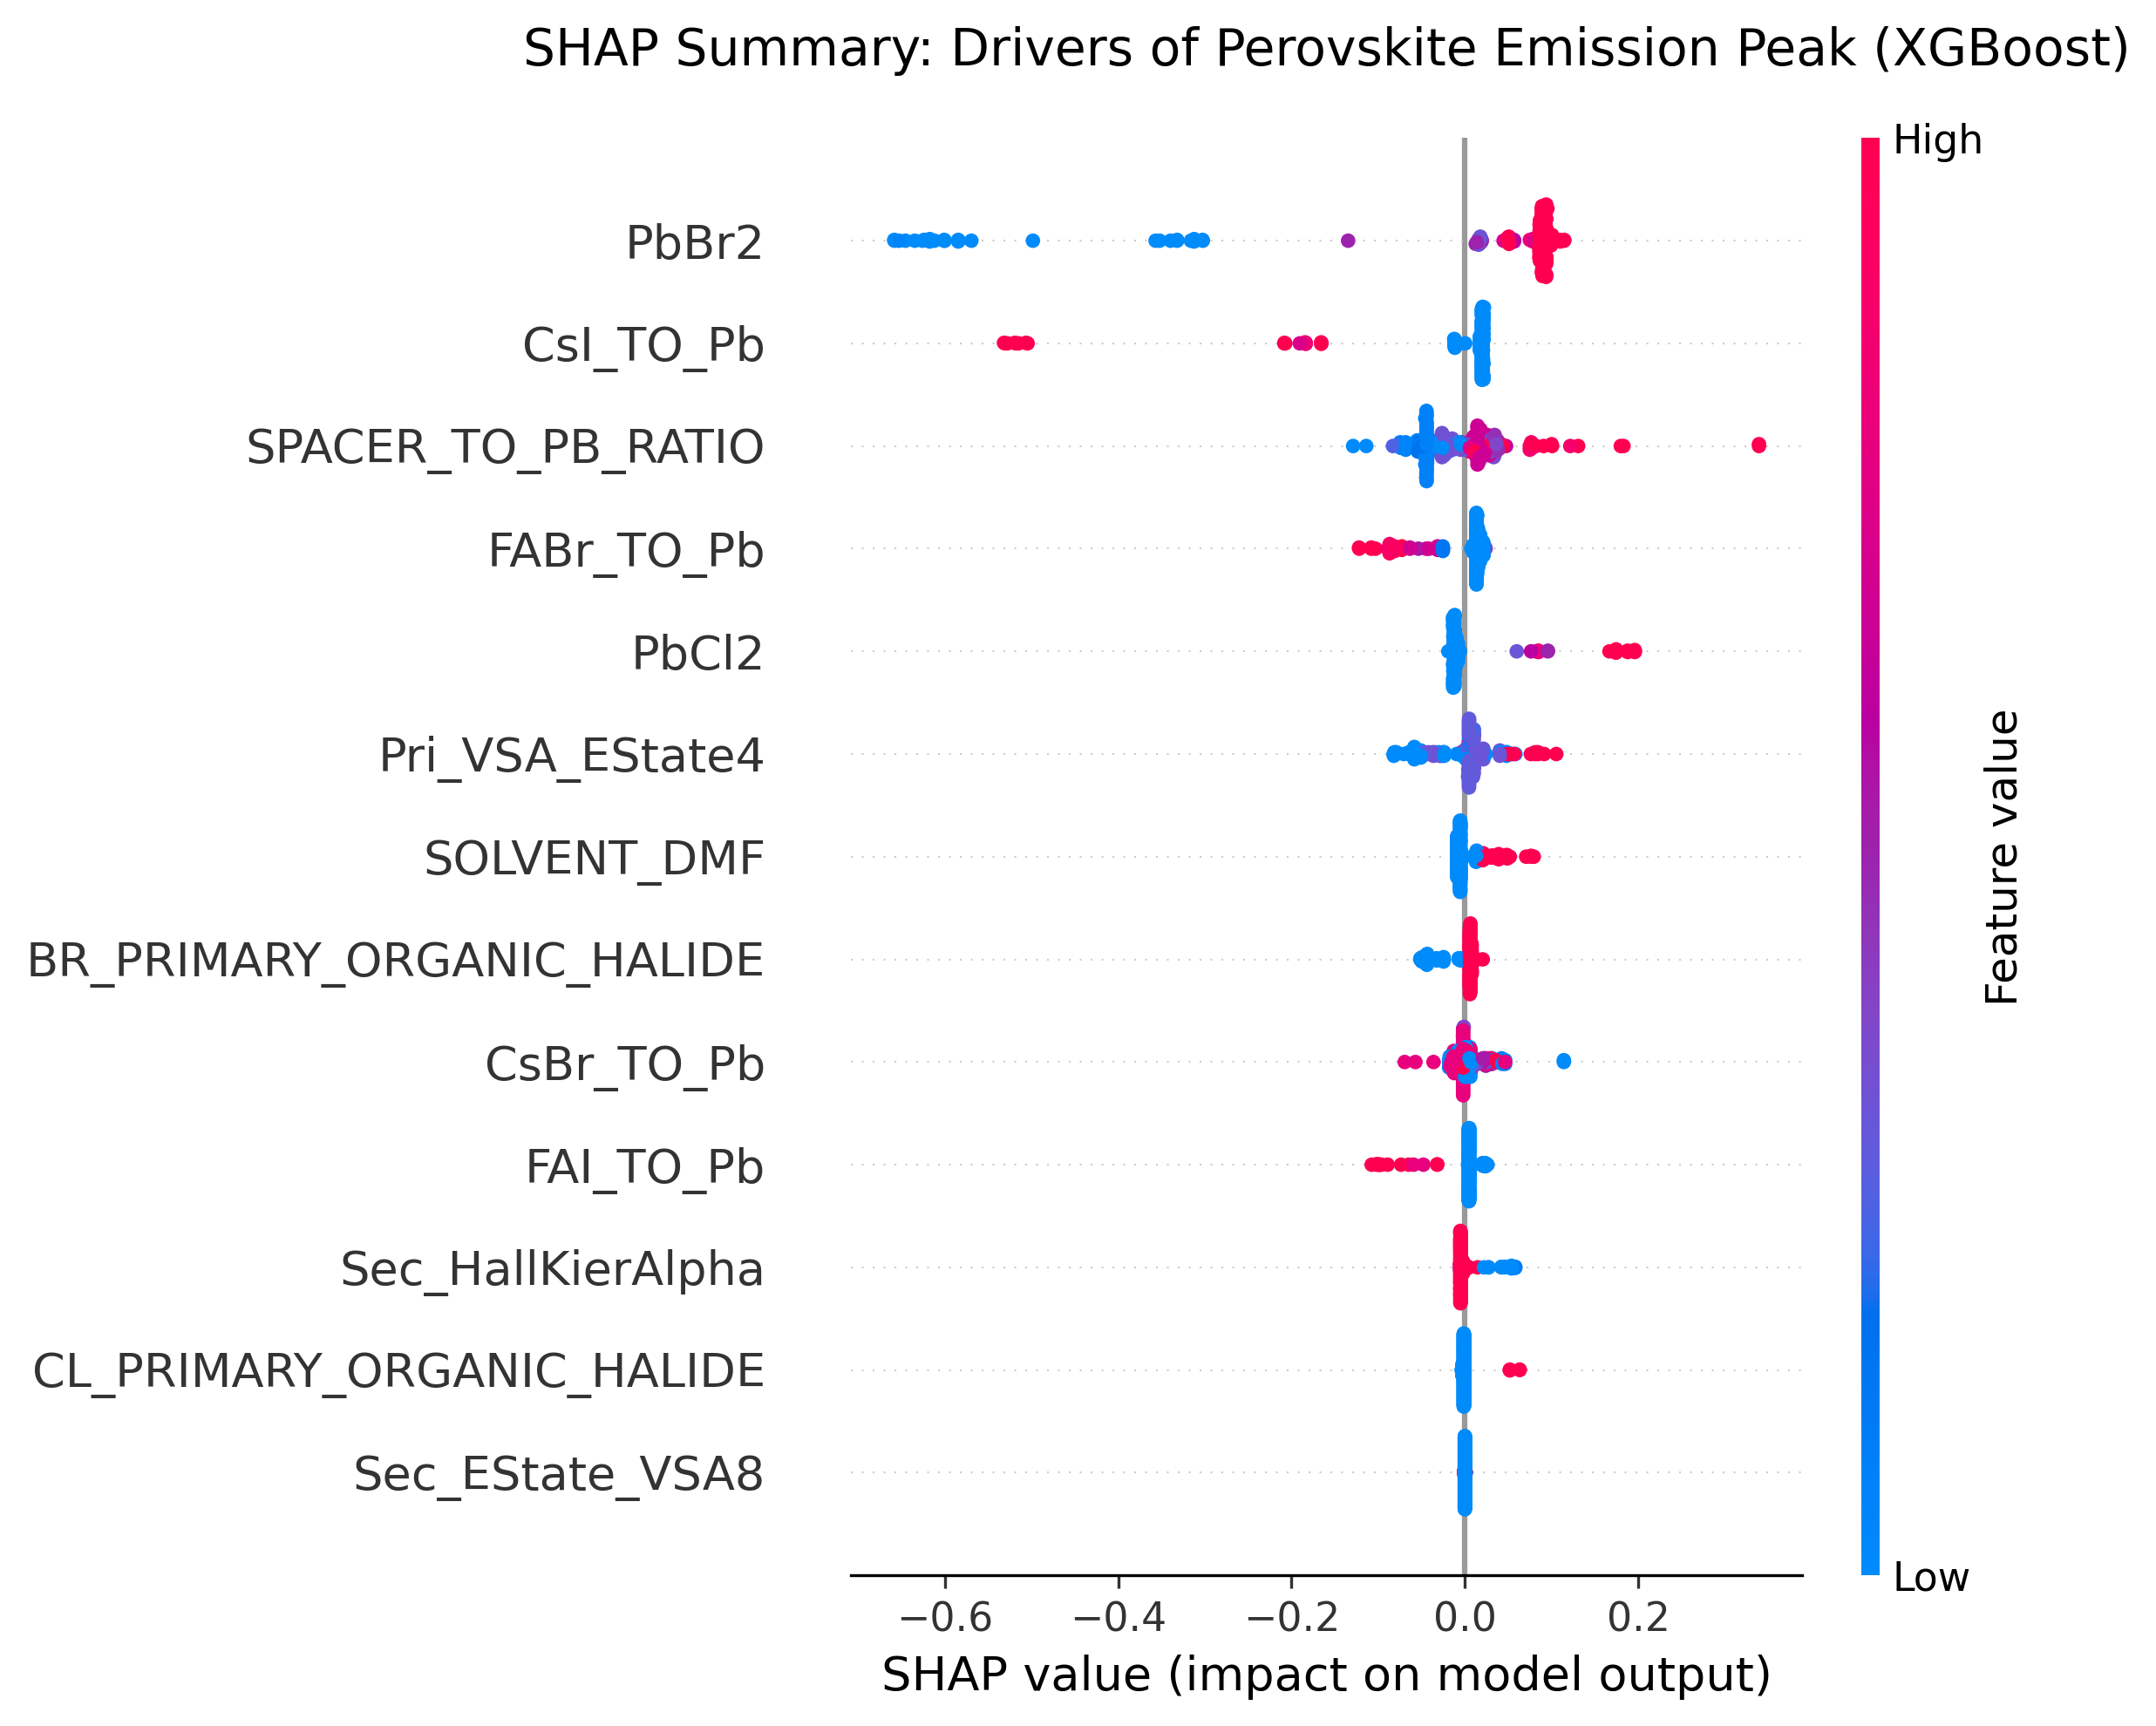

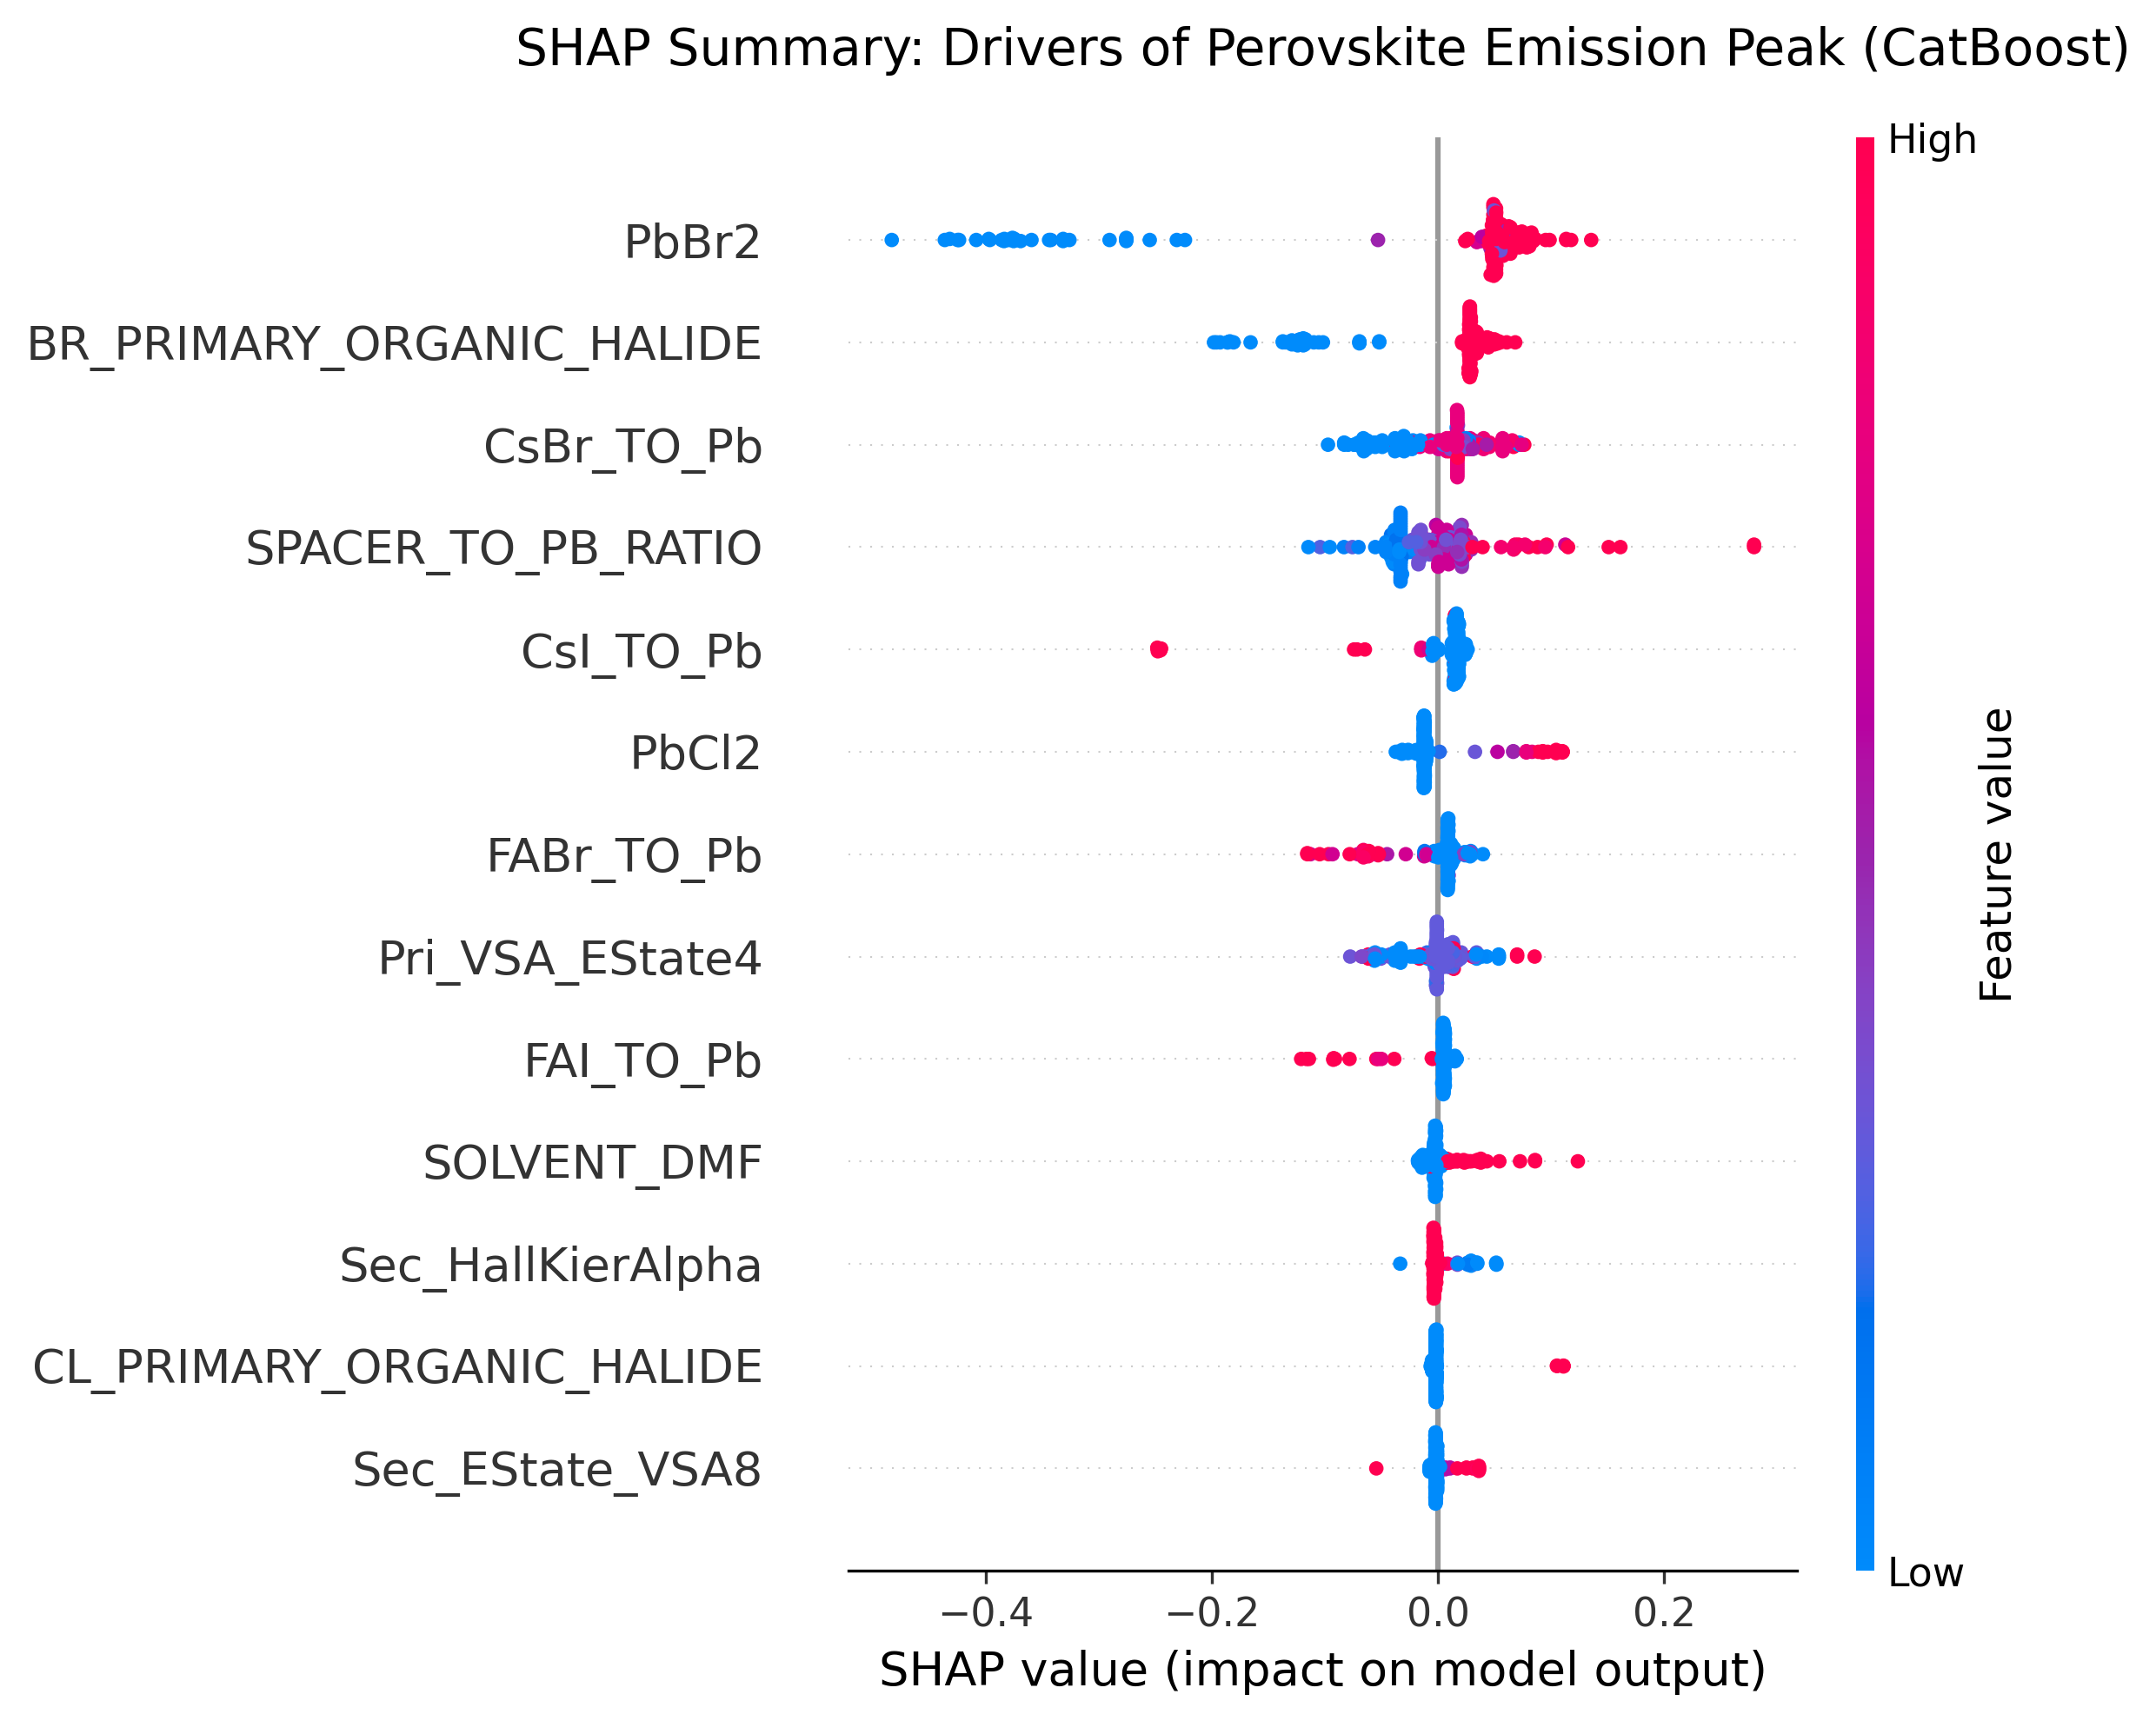

  0%|          | 0/57 [00:00<?, ?it/s]

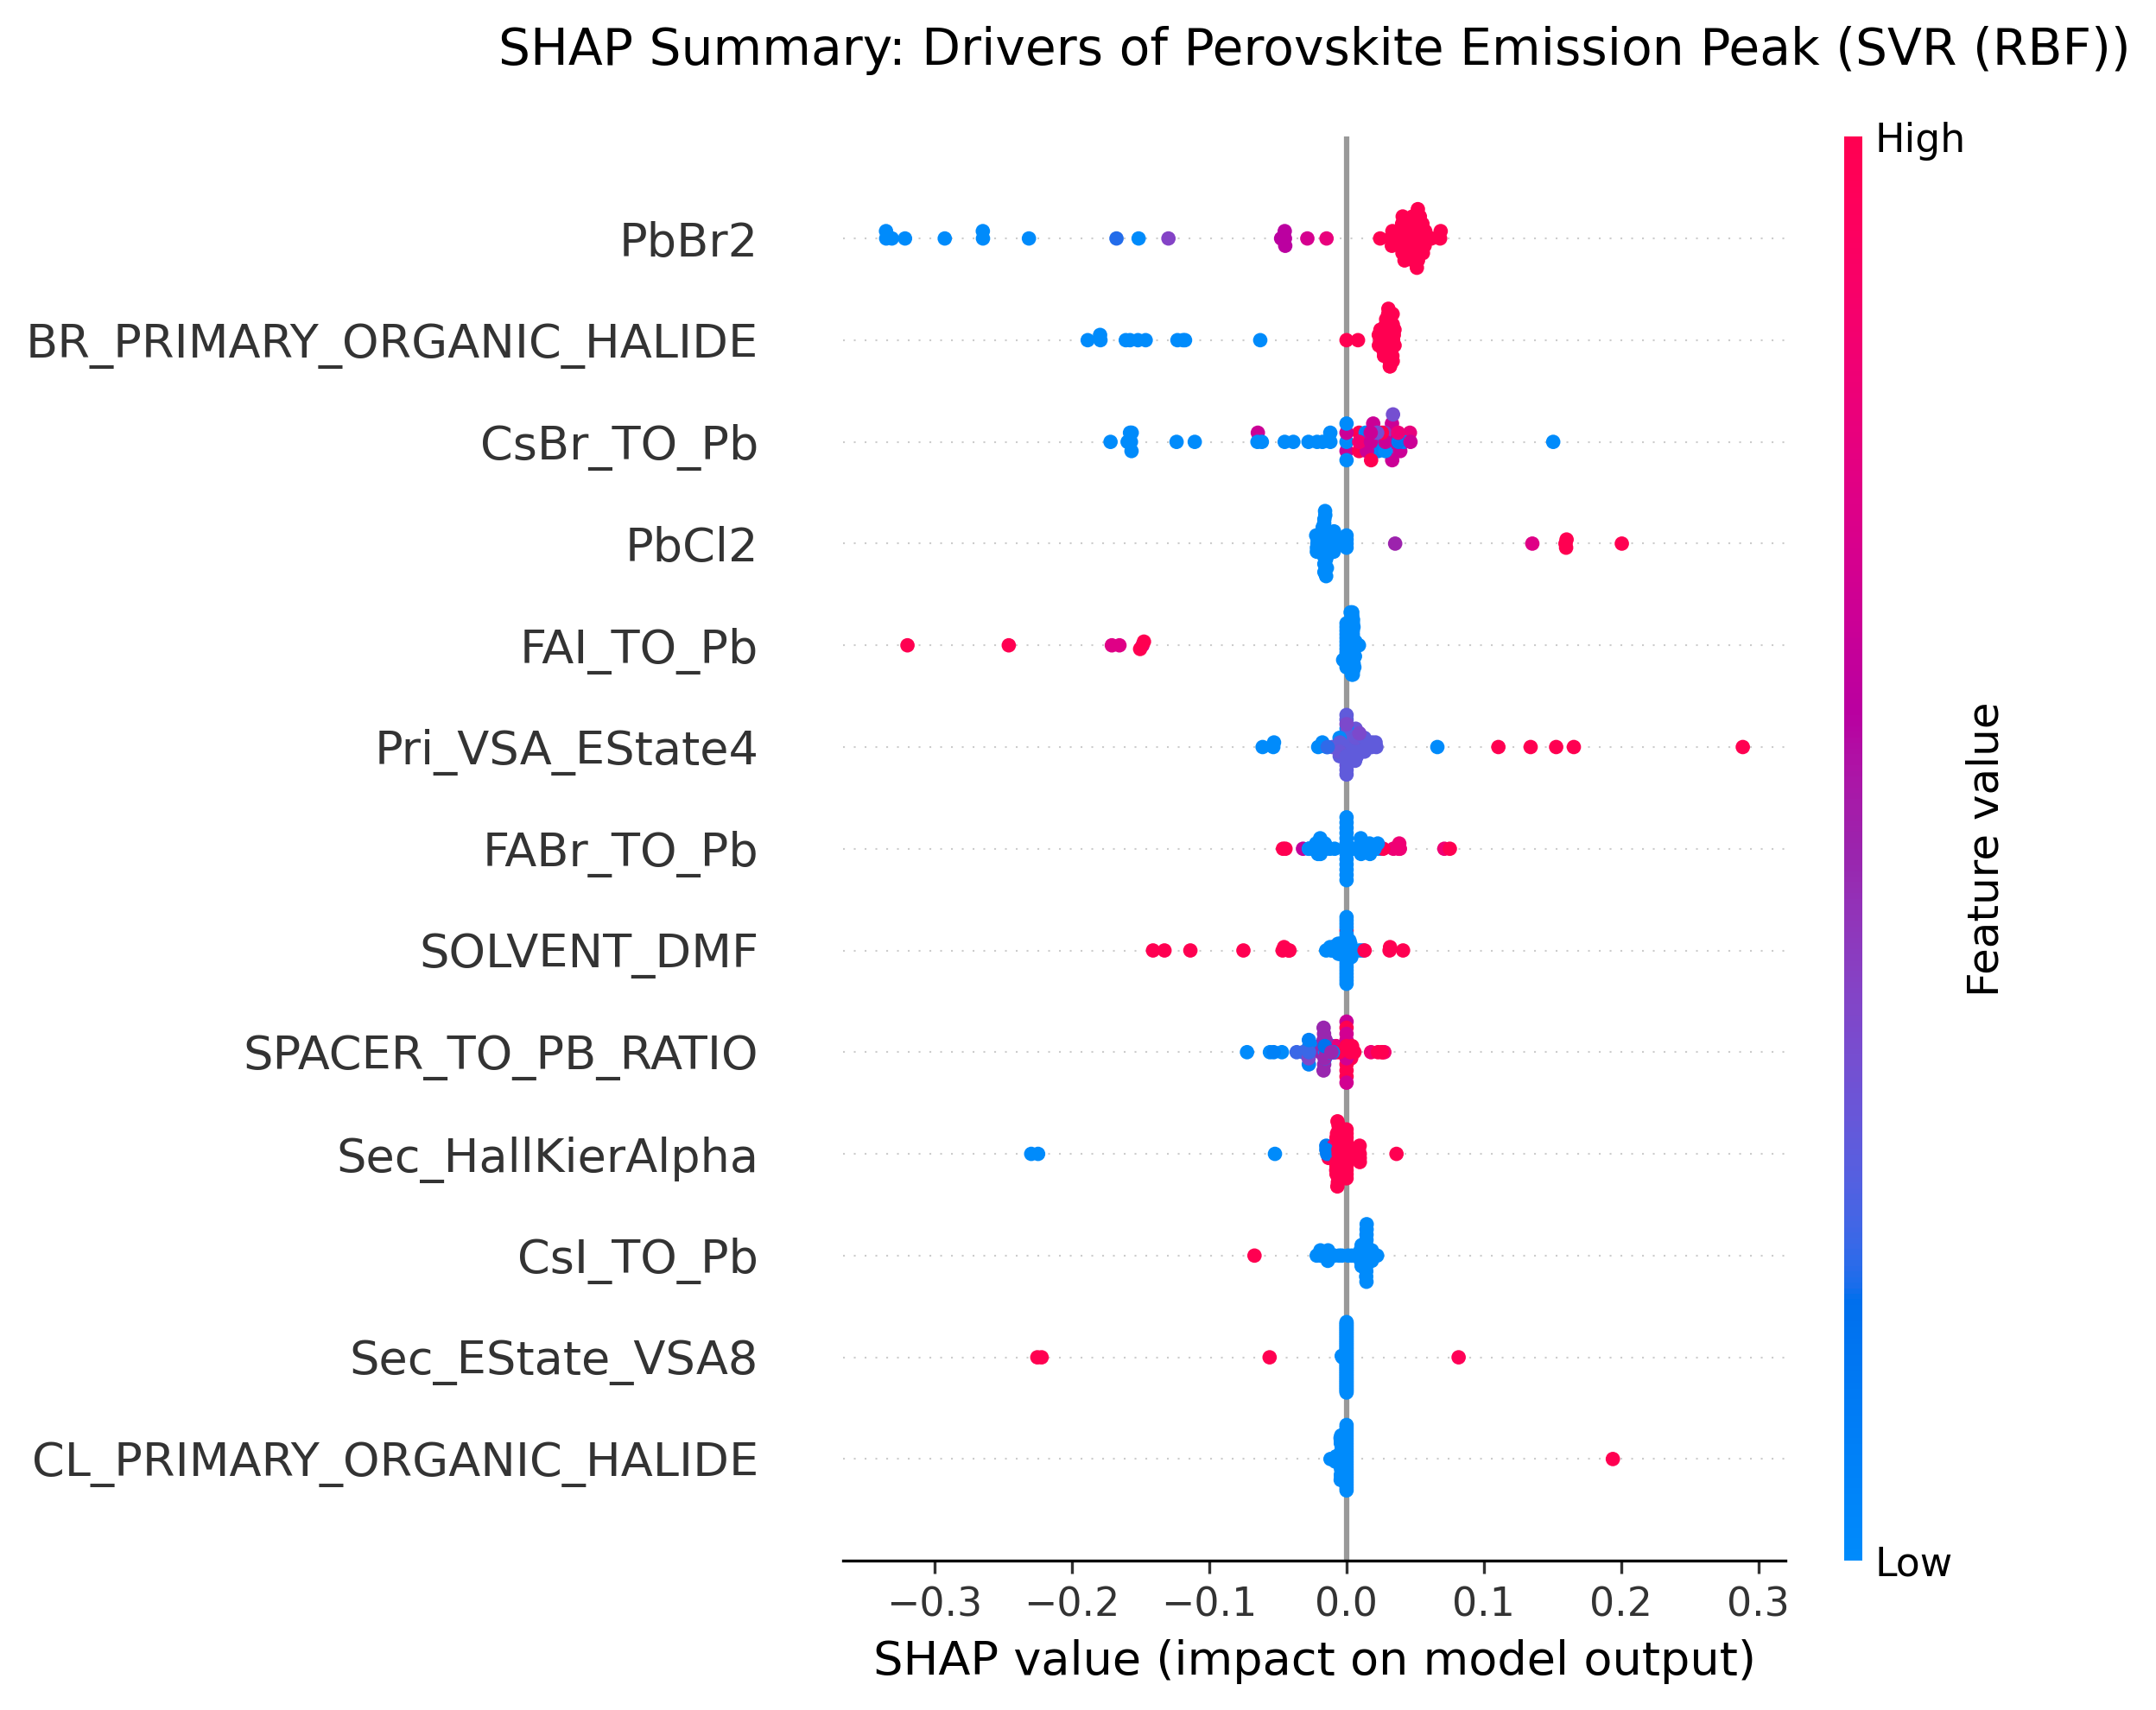

  0%|          | 0/57 [00:00<?, ?it/s]

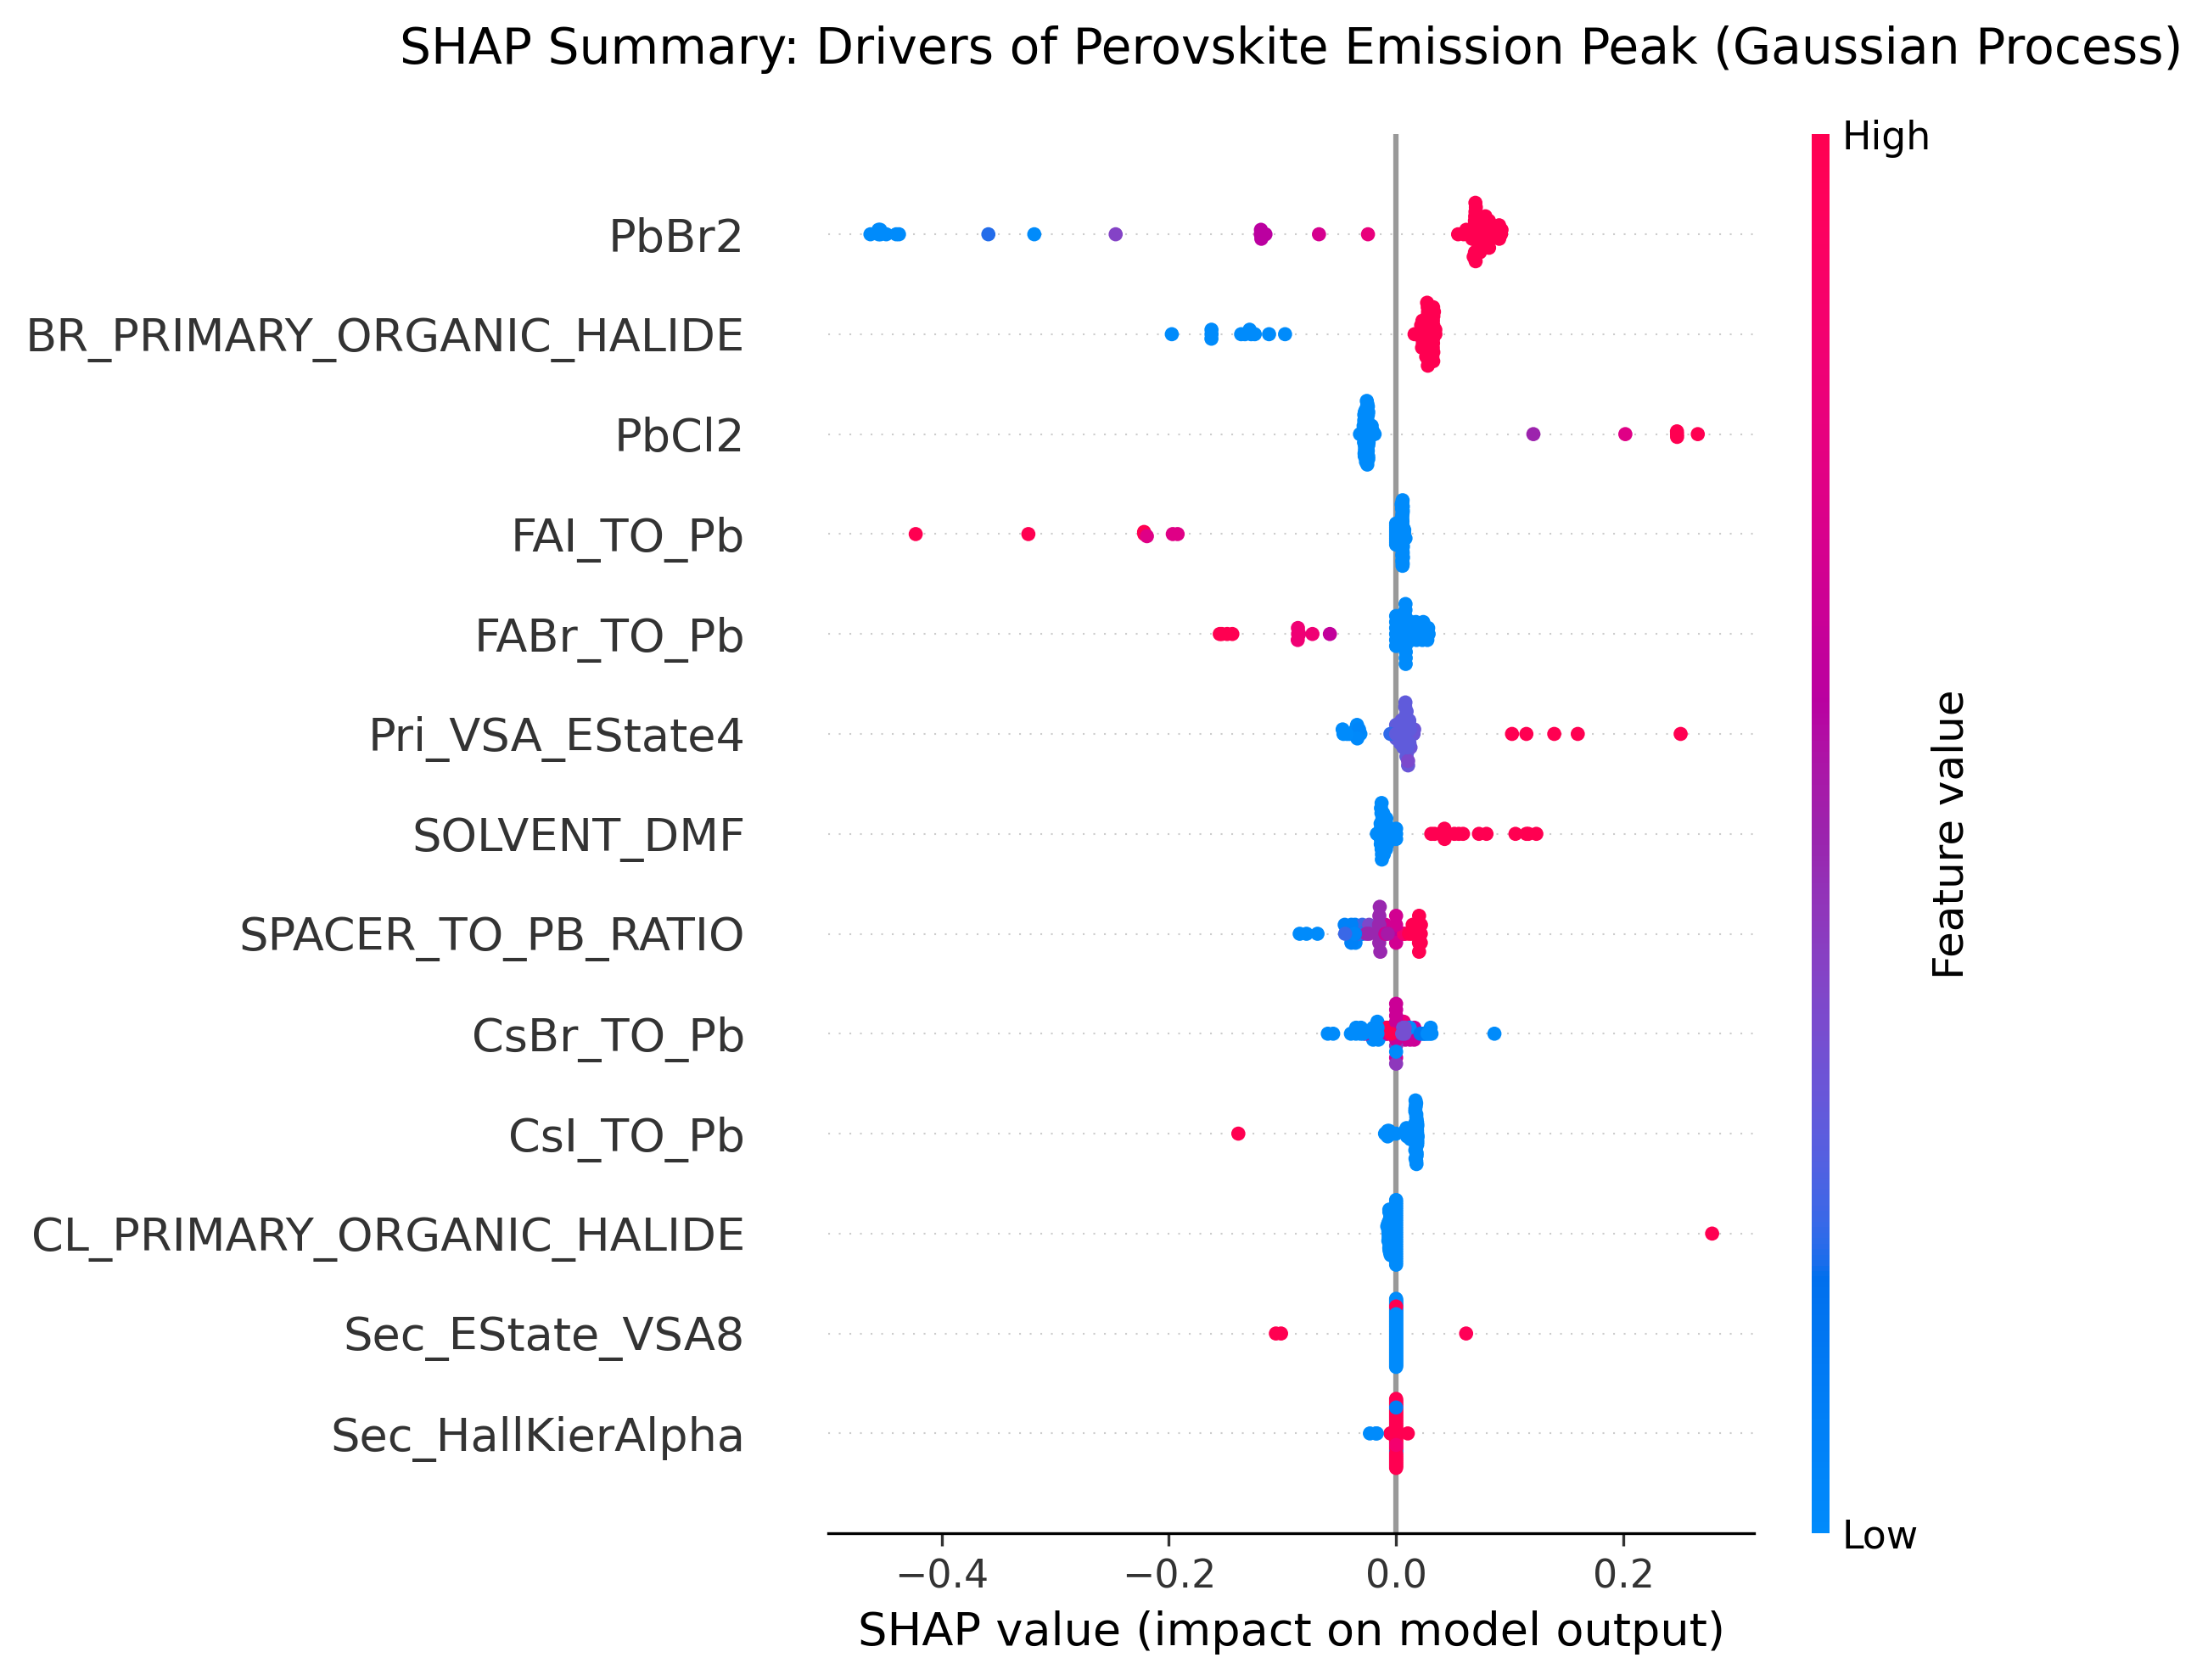

In [10]:
# --- IMPORTS FOR TUNING ---
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. SCALE THE DATA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# ==========================================
# 2. HYPERPARAMETER TUNING & INITIALIZATION
# ==========================================
print("Starting Hyperparameter Tuning (this may take a few minutes)...")

# Define hyperparameter grids for each model
param_grids = {
    "Random Forest": {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [100, 300, 500],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1]
    },
    "CatBoost": {
        'iterations': [300, 500, 800],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1]
    },
    "SVR (RBF)": {
        'C': [0.1, 1, 10, 50],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.2]
    }
}

# Define the base models
base_models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_seed=42, verbose=0),
    "SVR (RBF)": SVR(kernel='rbf')
}

models = {} # This will store our final, fully optimized models

# Run Randomized Search for each base model
for name, model in base_models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=15,             # Tests 15 random combinations per model
        cv=5,                  # 5-fold cross-validation
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1              # Use all CPU cores to speed up
    )
    
    # Fit the search on the scaled training data
    search.fit(X_train_scaled, y_train)
    
    # Save the absolute best model
    models[name] = search.best_estimator_
    print(f"--> Best params for {name}: {search.best_params_}")

# Add Gaussian Process Regressor (GPR optimizes its own kernel automatically)
print("Tuning Gaussian Process...")
gpr_kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gpr_model = GaussianProcessRegressor(kernel=gpr_kernel, random_state=42, n_restarts_optimizer=5)
gpr_model.fit(X_train_scaled, y_train)
models["Gaussian Process"] = gpr_model

print("\nAll models successfully tuned and trained!\n")


# ==========================================
# 3. EVALUATION OF BEST MODELS
# ==========================================
results = []

for name, model in models.items():
    # Model is already fitted with the best parameters, so we just predict
    y_pred_eV_loop = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred_eV_loop)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_eV_loop))
    mae = mean_absolute_error(y_test, y_pred_eV_loop)
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE (eV)": rmse,
        "MAE (eV)": mae
    })

benchmark_df = pd.DataFrame(results).sort_values(by="RMSE (eV)", ascending=True).reset_index(drop=True)
print("FINAL RESULTS (Using Tuned Hyperparameters)")
print(benchmark_df.to_string(index=False))


# ==========================================
# 4. SHAP PLOTS FOR EACH MODEL
# ==========================================
print("\nGenerating SHAP Summary Plots for each model... (SVR and GPR may take a moment)")

background_data = shap.sample(X_train_scaled, 50) 

for name, model in models.items():
    plt.figure(figsize=(10, 8), dpi=300)
    
    # --- For Tree-Based Models ---
    if name in ["Random Forest", "CatBoost", "XGBoost"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_train_scaled)
        
        # Replace scaled data with real unscaled values for interpretable axes
        shap_values.data = X_train_final.values 
        shap_values.feature_names = X_train_final.columns.tolist()
        
        shap.plots.beeswarm(shap_values, max_display=15, show=False)
        
    # --- For Mathematical Models (SVR & GPR) ---
    else:
        # KernelExplainer treats the model as a black box
        explainer = shap.KernelExplainer(model.predict, background_data)
        
        # Calculate SHAP values on the test set to save time
        shap_values_raw = explainer.shap_values(X_test_scaled)
        
        shap.summary_plot(
            shap_values_raw, 
            features=X_test_final, 
            feature_names=X_test_final.columns.tolist(), 
            max_display=20, 
            show=False
        )

    plt.title(f"SHAP Summary: Drivers of Perovskite Emission Peak ({name})", fontsize=14, pad=20)
    plt.tight_layout()
    
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f"Figure_SHAP_{safe_name}_RFECV_eV_Tuned.png", bbox_inches='tight')
    plt.show()